In [477]:
import pandas as pd
import scipy
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random
import copy

In [525]:
IS_TESTING = 0
BEST_WINDOW = 33

In [497]:
if IS_TESTING == 1:
    data = scipy.io.loadmat('../Data/fake_test.mat')
    test = data['pred_var']
    test_data = test.astype(np.float32).flatten()

In [498]:
mat_data = scipy.io.loadmat('../Data/Xtrain.mat')


In [499]:
print(mat_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


In [500]:
X = mat_data['Xtrain']
print(f"Feature shape: {X.shape}")

Feature shape: (1000, 1)


In [501]:
raw_data = X.astype(np.float32).flatten()

In [502]:
def create_data(data, window):
    rows = [data[i : i + window] for i in range(len(data) - window + 1)]
    columns = [f"x{i}" for i in range(window - 1)] + ["y"]

    return pd.DataFrame(rows, columns=columns)

In [503]:
split_idx = int(len(raw_data) * 0.8)
train_raw = np.array(raw_data[:split_idx]).reshape(-1, 1)
test_raw = np.array(raw_data[split_idx:]).reshape(-1, 1)

# 2. Fit the scaler ONLY on training data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw).flatten()

test_scaled = scaler.transform(test_raw).flatten()

In [486]:
class LaserDataset(Dataset):
    def __init__(self, df):
        # Separate features (X) and target (y)
        self.X = torch.tensor(df.drop('y', axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df['y'].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [487]:
class LaserPredictor(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(LaserPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 64 outputs
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 32 outputs
            
            nn.Linear(32, 1) # Never put dropout on the final output layer
        )

    def forward(self, x):
        return self.network(x)

In [528]:
model = LaserPredictor(input_size=BEST_WINDOW) # Replace 10 with your actual input size
print(model)

LaserPredictor(
  (network): Sequential(
    (0): Linear(in_features=33, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [488]:
def recursive_data_generation(x, model, k, num_samples) -> np.ndarray:
    """
    x: current_window
    model: model
    k: window size
    num_samples: number of predictions
    """
    # Evaluation Mode
    model.eval()

    # Initialize predicted samples array
    predicted_samples = np.zeros(num_samples, dtype=np.float32)

    # Make sure x is torch.tensor and not np.ndarray

    x = torch.tensor(x, dtype=torch.float32)

    # Make sure len(x) == k
    if len(x) > k:
        x = x[-k:].clone()
    elif len(x) < k:
        print(f"Window size of x must be at least {k} samples long")
        return np.empty((0, num_samples), dtype=np.float32)


    with torch.no_grad():
        for i in range(num_samples):
            # Predict next sample
            y = model(x)
            # Concatenate last-k window
            x = torch.cat([x[1:], y])
            # Add to prediction samples array
            predicted_samples[i] = y.item()

    return predicted_samples

In [489]:
if IS_TESTING == 0:
    # Configuration
    window_sizes = [i for i in range(3, 151)]
    shuffle_options = [True, False]
    # seeds = [42, 123, 999, 7, 2024, 222, 153, 23, 1111, 1263] # 10 different seeds
    seeds = [random.randint(0, 2000) for _ in range(10)]
    print(seeds)
    epochs = 100 # Reduced slightly for the search; you can set back to 100
    results = []

    def set_seed(seed):
        """Utility to ensure reproducibility for each trial"""
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    shuffle_flag = True
    for w in window_sizes:
            
            # Store val losses for the 5 seeds to average them later
            seed_val_losses = []
            seed_train_losses = []
            
            for seed in seeds:
                set_seed(seed) # Reset math state for this specific trial
                # print(f"seed value: {seed}")
                
                # 1. Re-generate data
                df_train = create_data(train_scaled, window=w)
                df_test = create_data(test_scaled, window=w)
                
                train_loader = DataLoader(LaserDataset(df_train), batch_size=32, shuffle=shuffle_flag)
                test_loader = DataLoader(LaserDataset(df_test), batch_size=32, shuffle=False)
                
                # 2. Initialize Model
                model = LaserPredictor(input_size=w - 1)
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
                criterion = torch.nn.MSELoss()
                
                # 3. Training Loop
                for epoch in range(epochs):
                    model.train()
                    total_train_loss = 0
                    for batch_X, batch_y in train_loader:
                        optimizer.zero_grad()
                        loss = criterion(model(batch_X), batch_y)
                        loss.backward()
                        optimizer.step()
                        total_train_loss += loss.item()
                    
                    # We calculate validation at the END of the training for this seed
                    if epoch == epochs - 1:
                        window = list(train_scaled[-(w-1):])
                        preds = recursive_data_generation(x=window,model=model,k=w-1,num_samples=len(test_scaled))
                        recursive_val_mse = mean_squared_error(test_scaled, preds)
                        
                        seed_val_losses.append(recursive_val_mse)
                        seed_train_losses.append(total_train_loss / len(train_loader))

            # 4. Calculate averages across the 5 seeds
            avg_val_loss = np.mean(seed_val_losses)
            avg_train_loss = np.mean(seed_train_losses)
            std_val_loss = np.std(seed_val_losses) # Also useful to see how "stable" the window is

            results.append({
                'window_size': w,
                'shuffled': shuffle_flag,
                'avg_train_loss': avg_train_loss,
                'avg_val_loss': avg_val_loss,
                'val_std_dev': std_val_loss
            })

    # 5. Final Results
    results_df = pd.DataFrame(results)
    aa = results_df.sort_values('avg_val_loss').head(10)["window_size"].values[0:10]
    print(f"best windows: {aa}")
    print(f"\nFinal Experiment Results (Averaged over {len(seeds)} seeds):")
    print(results_df.sort_values('avg_val_loss').head(10)) # Show top 10 configurations
else:
    print("Hyper parameter omptimization is skipped due to testing settings")

[247, 693, 1318, 463, 592, 1929, 1494, 1285, 1925, 790]
best windows: [146  61 115 128 101  64  42  74  22  10]

Final Experiment Results (Averaged over 10 seeds):
     window_size  shuffled  avg_train_loss  avg_val_loss  val_std_dev
143          146      True        0.002709      0.025918     0.009623
58            61      True        0.002453      0.026636     0.010909
112          115      True        0.002643      0.028145     0.010335
125          128      True        0.003298      0.028153     0.008501
98           101      True        0.002444      0.028583     0.009387
61            64      True        0.002834      0.029108     0.008503
39            42      True        0.001905      0.029259     0.007820
71            74      True        0.002306      0.029307     0.010192
19            22      True        0.001835      0.029338     0.010303
7             10      True        0.001910      0.029652     0.009986


[691, 1535, 132, 1782, 771, 1228, 1743, 323, 1292, 1813]

best windows: [  5 145 136 110  16 138 141  57  83  42]


[1576, 1000, 610, 1097, 152, 454, 1153, 598, 1820, 1869]

best windows: [138  93 121  85 142  60  48  10  36  76]


[1859, 173, 473, 207, 1510, 965, 1744, 723, 1176, 652]

best windows: [ 68  52  91  42 128  46 130  39 146 103]


[844, 319, 835, 127, 1838, 350, 1839, 84, 628, 250]

best windows: [ 35 137  64  43 146 140 113  19 105 149]


[400, 1210, 621, 1211, 695, 1841, 377, 1484, 702, 581]

best windows: [ 33 121 145  71   8  16 105  31 122 136]


[1973, 986, 1349, 1422, 893, 1617, 1722, 1374, 444, 986]

best windows: [134  40 122 125 106  55  32  20  57 130]


[471, 1013, 662, 919, 1416, 522, 1491, 534, 1536, 1413]

best windows: [ 21 114 111 135 143   8 121 148  63 139]


[847, 1384, 814, 485, 1261, 470, 935, 1695, 1097, 1848]

best windows: [ 33 126  28  60 127  91 125 114  38 146]


[386, 1652, 1516, 1494, 1111, 1930, 1936, 587, 443, 481]

best windows: [ 94 135 115  87 109  54  56 110   4 134]


[58, 1397, 384, 819, 411, 14, 1194, 1096, 1928, 455]

best windows: [118 105  62 139  46 114 119 140  22 109]

In [490]:
if IS_TESTING == 0:
    BEST_WINDOW = results_df.sort_values('avg_val_loss').head(1)["window_size"].values[0]
# BEST_WINDOW = int(BEST_WINDOW.mean())

In [491]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, path='best_checkpoint.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [529]:
if IS_TESTING == 0:
    # 1. Final Configuration

    SHUFFLE_TRAIN = True
    EPOCHS = 500 
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    PATIENCE = 100

    seeds = [random.randint(0, 2000) for _ in range(10)]
    trained_models = [] # This will store your 10 best models

    # 2. Data Preparation (Fixed for all seeds)
    df_train = create_data(train_scaled, window=BEST_WINDOW)
    train_loader = DataLoader(LaserDataset(df_train), batch_size=64, shuffle=SHUFFLE_TRAIN)

    # 3. Outer Loop: Iterate through each seed
    for i, seed in enumerate(seeds):
        print(f"\n=== Training Model {i+1}/10 | Seed: {seed} ===")
        set_seed(seed) # Ensure reproducibility for this specific run
        
        # Initialize Model, Optimizer, and Early Stopper
        model = LaserPredictor(input_size=BEST_WINDOW - 1)
        # model.apply(init_weights_kaiming) # Apply the Kaiming initialization
        
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        criterion = torch.nn.MSELoss()
        
        # Unique path for each seed's best checkpoint
        checkpoint_path = f'model{i}.pth'
        early_stopper = EarlyStopping(patience=PATIENCE, path=checkpoint_path)

        # 4. Training Loop
        for epoch in range(EPOCHS):
            # --- TRAINING PHASE ---
            model.train()
            total_train_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
            
            # --- RECURSIVE VALIDATION PHASE ---
            window = list(train_scaled[-(BEST_WINDOW-1):])
            # print(f"window: {window}")
            preds = recursive_data_generation(x=window,model=model,k=BEST_WINDOW-1,num_samples=len(test_scaled))
            recursive_val_mse = mean_squared_error(test_scaled, preds)
            
                    
            avg_train = total_train_loss / len(train_loader)
            
            # Check early stopping against the recursive performance
            early_stopper(recursive_val_mse, model)
            
            if (epoch + 1) % 20 == 0:
                print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train:.6f} | Rec-Val MSE: {recursive_val_mse:.6f}")

            if early_stopper.early_stop:
                print(f"Early stopping at epoch {epoch+1}. Best Rec-Val MSE: {early_stopper.best_loss:.6f}")
                break

        # 5. Load best weights and store the model
        model.load_state_dict(torch.load(checkpoint_path))
        trained_models.append(copy.deepcopy(model)) # Store the best version of this model
        print(f"Model {i+1} saved to list.")

    print("\nAll 10 models have been trained and stored in 'trained_models'.")
    joblib.dump(scaler, 'laser_scaler_ensemble.pkl')
else:
    print("Model training is skipped due to testing")


=== Training Model 1/10 | Seed: 182 ===
Epoch [20/500] | Train Loss: 0.007317 | Rec-Val MSE: 0.075509
Epoch [40/500] | Train Loss: 0.004607 | Rec-Val MSE: 0.049983
Epoch [60/500] | Train Loss: 0.003392 | Rec-Val MSE: 0.065612
Epoch [80/500] | Train Loss: 0.002909 | Rec-Val MSE: 0.012866
Epoch [100/500] | Train Loss: 0.002739 | Rec-Val MSE: 0.037802
Epoch [120/500] | Train Loss: 0.002276 | Rec-Val MSE: 0.011505
Early stopping at epoch 131. Best Rec-Val MSE: 0.001796
Model 1 saved to list.

=== Training Model 2/10 | Seed: 1426 ===
Epoch [20/500] | Train Loss: 0.006889 | Rec-Val MSE: 0.030148
Epoch [40/500] | Train Loss: 0.004029 | Rec-Val MSE: 0.036791
Epoch [60/500] | Train Loss: 0.003261 | Rec-Val MSE: 0.036374
Epoch [80/500] | Train Loss: 0.002760 | Rec-Val MSE: 0.036622
Epoch [100/500] | Train Loss: 0.002055 | Rec-Val MSE: 0.040466
Epoch [120/500] | Train Loss: 0.002671 | Rec-Val MSE: 0.030250
Early stopping at epoch 135. Best Rec-Val MSE: 0.001260
Model 2 saved to list.

=== Traini

In [530]:
# if IS_TESTING == 0:
#     # 1. Final Configuration
#     SHUFFLE_TRAIN = True
#     EPOCHS = 500 
#     LEARNING_RATE = 0.001
#     WEIGHT_DECAY = 1e-4
#     PATIENCE = 100

#     seeds = [random.randint(0, 2000) for _ in range(10)]
#     trained_models = [] 
#     all_val_histories = [] # NEW: To store MSE history for each seed

#     # 2. Data Preparation
#     df_train = create_data(train_scaled, window=BEST_WINDOW)
#     train_loader = DataLoader(LaserDataset(df_train), batch_size=64, shuffle=SHUFFLE_TRAIN)

#     # 3. Outer Loop: Iterate through each seed
#     for i, seed in enumerate(seeds):
#         print(f"\n=== Training Model {i+1}/10 | Seed: {seed} ===")
#         set_seed(seed)
        
#         model = LaserPredictor(input_size=BEST_WINDOW - 1)
#         optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
#         criterion = torch.nn.MSELoss()
        
#         checkpoint_path = f'model{i}.pth'
#         early_stopper = EarlyStopping(patience=PATIENCE, path=checkpoint_path)
        
#         seed_val_history = [] # NEW: History for current seed

#         # 4. Training Loop
#         for epoch in range(EPOCHS):
#             # --- TRAINING PHASE ---
#             model.train()
#             total_train_loss = 0
#             for batch_X, batch_y in train_loader:
#                 optimizer.zero_grad()
#                 loss = criterion(model(batch_X), batch_y)
#                 loss.backward()
#                 optimizer.step()
#                 total_train_loss += loss.item()
            
#             # --- RECURSIVE VALIDATION PHASE ---
#             model.eval() # Ensure eval mode for recursive step
#             with torch.no_grad():
#                 window = list(train_scaled[-(BEST_WINDOW-1):])
#                 preds = recursive_data_generation(x=window, model=model, k=BEST_WINDOW-1, num_samples=len(test_scaled))
#                 recursive_val_mse = mean_squared_error(test_scaled, preds)
            
#             seed_val_history.append(recursive_val_mse) # NEW: Record the score
#             avg_train = total_train_loss / len(train_loader)
            
#             # Early stopping check
#             early_stopper(recursive_val_mse, model)
            
#             if (epoch + 1) % 20 == 0:
#                 print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train:.6f} | Rec-Val MSE: {recursive_val_mse:.6f}")

#             if early_stopper.early_stop:
#                 print(f"Early stopping at epoch {epoch+1}. Best Rec-Val MSE: {early_stopper.best_loss:.6f}")
#                 break

#         all_val_histories.append(seed_val_history) # NEW: Store seed history
        
#         # 5. Load best weights and store
#         model.load_state_dict(torch.load(checkpoint_path))
#         trained_models.append(copy.deepcopy(model))
#         print(f"Model {i+1} saved to list.")

#     # --- NEW: PLOTTING THE VALIDATION SCORES ---
#     plt.figure(figsize=(12, 7))
#     for i, history in enumerate(all_val_histories):
#         plt.plot(history, alpha=0.6, label=f'Seed {seeds[i]} (Model {i+1})')
    
#     plt.title('Recursive Validation MSE History (All Seeds)')
#     plt.xlabel('Epochs')
#     plt.ylabel('Mean Squared Error')
#     plt.yscale('log') # Use log scale because MSE can drop exponentially
#     plt.grid(True, which="both", ls="-", alpha=0.2)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.show()

#     print("\nAll 10 models have been trained and stored.")
#     joblib.dump(scaler, 'laser_scaler_ensemble.pkl')

# else:
#     print("Model training is skipped due to testing")

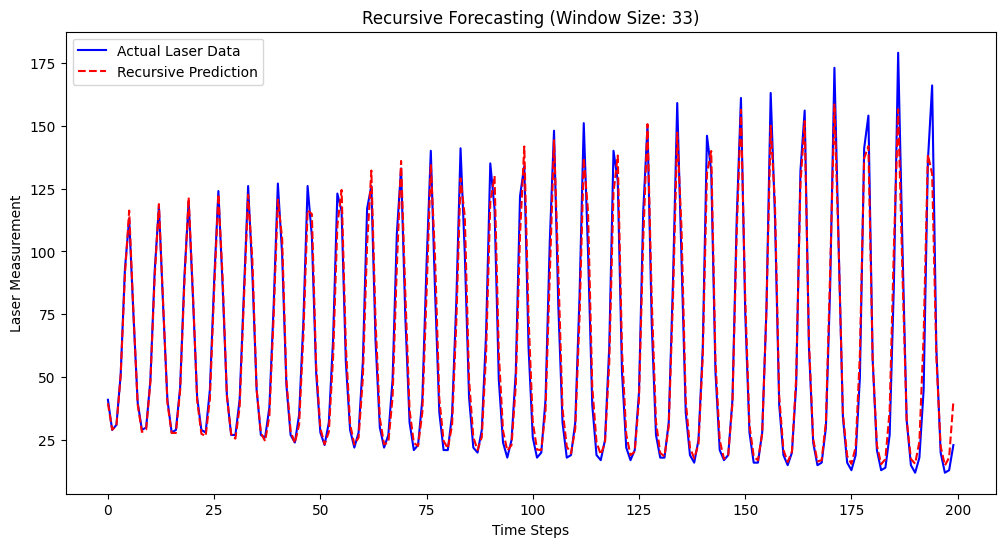

--- Recursive Forecast Metrics (Original Units) ---
MAE : 5.0687
MSE : 51.0341
RMSE: 7.1438


In [531]:
if IS_TESTING == 0:
    # Assuming window size is 15, so input_size is 14
    k_minus_1 = BEST_WINDOW - 1

    # 1. Take the last points from the SCALED training data
    current_window = list(train_scaled[-k_minus_1:])

    # 2. Collect predictions from every model in the ensemble
    all_model_runs = []

    for i, model in enumerate(trained_models):
        model.eval() # Ensure model is in inference mode
        # Generate recursive predictions for this specific model
        preds = recursive_data_generation(
            x=current_window, 
            model=model, 
            k=k_minus_1, 
            num_samples=len(test_scaled)
        )
        all_model_runs.append(preds)

    # 3. Calculate the average across all models (Ensemble Averaging)
    # all_model_runs is a list of arrays; np.mean(..., axis=0) averages them point-by-point
    avg_predictions = np.mean(all_model_runs, axis=0).reshape(-1, 1)

    # 4. Inverse transform and save
    final_forecast = scaler.inverse_transform(avg_predictions)
    scipy.io.savemat('predictions.mat', {'pred_var': final_forecast})
    actual_test_values = scaler.inverse_transform(test_scaled.reshape(-1, 1))

    plt.figure(figsize=(12, 6))
    plt.plot(actual_test_values, label='Actual Laser Data', color='blue')
    plt.plot(final_forecast, label='Recursive Prediction', color='red', linestyle='--')
    plt.title(f"Recursive Forecasting (Window Size: {k_minus_1+1})")
    plt.xlabel("Time Steps")
    plt.ylabel("Laser Measurement")
    plt.legend()
    plt.show()

    mae = mean_absolute_error(actual_test_values, final_forecast)
    mse = mean_squared_error(actual_test_values, final_forecast)
    rmse = np.sqrt(mse) # Root Mean Squared Error is also very helpful

    print(f"--- Recursive Forecast Metrics (Original Units) ---")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
else:
    print("Validation is skipped due to testing")

In [532]:
if IS_TESTING == 1:

    k_minus_1 = BEST_WINDOW - 1
    
    # 1. Take the last points from the SCALED training data as the starting window
    current_window = list(test_scaled[-k_minus_1:])
    
    # 2. Reconstruct and Load the 10 models from the file system
    trained_models = []
    print("Loading models from file system...")
    
    for i in range(10):
        # Must match the architecture used during training
        model = LaserPredictor(input_size=k_minus_1)
        
        # Load the specific weights for this seed/index
        checkpoint_path = f'model{i}.pth'
        model.load_state_dict(torch.load(checkpoint_path))
        
        # CRITICAL: Set to evaluation mode
        model.eval()
        trained_models.append(model)
        print(f"Successfully loaded {checkpoint_path}")

    # 3. Collect recursive predictions from every model in the ensemble
    all_model_runs = []
    print("\nRunning recursive predictions for each model...")
    
    for i, model in enumerate(trained_models):
        # Generate recursive predictions for this specific model
        preds = recursive_data_generation(
            x=current_window, 
            model=model, 
            k=k_minus_1, 
            num_samples=len(test_data)
        )
        all_model_runs.append(preds)
        print(f"Model {i} forecasting complete.")

    # 4. Calculate the average across all models
    avg_predictions = np.mean(all_model_runs, axis=0).reshape(-1, 1)

    # 5. Finalize data (Inverse transform and save)
    final_forecast = scaler.inverse_transform(avg_predictions)
    scipy.io.savemat('predictions.mat', {'pred_var': final_forecast})
    actual_test_values = scaler.inverse_transform(test_data.reshape(-1, 1))

    # 6. Visualization (Keep identical as requested)
    plt.figure(figsize=(12, 6))
    plt.plot(actual_test_values, label='Actual Laser Data', color='blue')
    plt.plot(final_forecast, label='Recursive Prediction (Ensemble)', color='red', linestyle='--')
    plt.title(f"Recursive Forecasting Ensemble (Window Size: {k_minus_1+1}, Models: {len(trained_models)})")
    plt.xlabel("Time Steps")
    plt.ylabel("Laser Measurement")
    plt.legend()
    plt.show()

    mae = mean_absolute_error(actual_test_values, final_forecast)
    mse = mean_squared_error(actual_test_values, final_forecast)

    print(f"--- Recursive Forecast Metrics (Original Units) ---")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")

In [533]:
# # --- Configuration ---
# k_minus_1 = BEST_WINDOW - 1
# # 1. Take the last points from the SCALED training data as starting window
# current_window = list(train_scaled[-k_minus_1:])

# # Convert to tensor and add batch dimension: shape (1, k_minus_1)
# x = torch.tensor(current_window, dtype=torch.float32).view(1, -1)

# res = []

# # --- Step-by-Step Ensemble Recursive Loop ---
# for i in range(len(test_scaled)):
#     current_preds = []

#     # 1. Get predictions from all 10 models for this specific time step
#     for model in trained_models:
#         model.eval()
#         with torch.no_grad():
#             # Get prediction and convert to scalar
#             pred_scalar = model(x).item()
#             current_preds.append(pred_scalar)

#     # 2. Average the predictions from all 10 models
#     current_avg_pred = np.mean(current_preds)
#     res.append(current_avg_pred)

#     # 3. Update the sliding window (x)
#     # Convert average prediction back to a tensor of shape (1, 1)
#     new_val_tensor = torch.tensor([[current_avg_pred]], dtype=torch.float32)

#     # Concatenate: take all columns except the first from x, and add the new value
#     # x[:, 1:] takes everything but the first element, shape (1, k_minus_1 - 1)
#     x = torch.cat([x[:, 1:], new_val_tensor], dim=1)

# # --- Post-Processing ---
# # Reshape res for inverse transformation
# res_array = np.array(res).reshape(-1, 1)
# final_forecast = scaler.inverse_transform(res_array)
# actual_test_values = scaler.inverse_transform(test_scaled.reshape(-1, 1))

# # --- Visualization ---
# plt.figure(figsize=(12, 6))
# plt.plot(actual_test_values, label="Actual Laser Data", color="blue")
# plt.plot(
#     final_forecast, label="Recursive Ensemble Prediction", color="red", linestyle="--"
# )
# plt.title(f"Ensemble Step-Averaged Recursive Forecasting (Window: {k_minus_1+1})")
# plt.xlabel("Time Steps")
# plt.ylabel("Laser Measurement")
# plt.legend()
# plt.show()

# # --- Metrics ---
# mae = mean_absolute_error(actual_test_values, final_forecast)
# mse = mean_squared_error(actual_test_values, final_forecast)
# rmse = np.sqrt(mse)

# print(f"--- Recursive Forecast Metrics (Original Units) ---")
# print(f"MAE : {mae:.4f}")
# print(f"MSE : {mse:.4f}")
# print(f"RMSE: {rmse:.4f}")